Imported Library

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

****

**configration**

In [2]:
SEEDS = [42, 123, 2026]

TASKS = [
    (0, 1),
    (2, 3),
    (4, 5),
    (6, 7),
    (8, 9)
]

NUM_TASKS = 5

BATCH_SIZE = 128

# Keep this small so the experiment finishes quickly
EPOCHS_PER_TASK = 3

LEARNING_RATE = 0.05
MOMENTUM = 0.9

# Maximum total replay memory
BUFFER_SIZE = 200

RESULTS_DIR = "results"
PLOTS_DIR = "plots"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("WHERE DID THE KNOWLEDGE GO?")
print("=" * 70)
print("Device:", DEVICE)
print("Tasks:", TASKS)
print("Seeds:", SEEDS)
print("=" * 70)


WHERE DID THE KNOWLEDGE GO?
Device: cpu
Tasks: [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]
Seeds: [42, 123, 2026]


**productablity# **

In [3]:
def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

**MINIST**

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

print("\nLoading MNIST...")

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("MNIST loaded.")


Loading MNIST...


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 356kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.19MB/s]

MNIST loaded.


In [5]:
class SubsetDataset(Dataset):

    def __init__(
        self,
        base_dataset,
        indices
    ):

        self.base_dataset = base_dataset
        self.indices = list(indices)

    def __len__(self):

        return len(self.indices)

    def __getitem__(self, index):

        image, label = self.base_dataset[
            self.indices[index]
        ]

        # Always return Tensor image
        if not torch.is_tensor(image):

            image = torch.tensor(
                image,
                dtype=torch.float32
            )

        # Always return integer label
        label = int(label)

        return image, label


In [6]:
def get_task_indices(
    dataset,
    classes
):

    targets = np.array(
        dataset.targets
    )

    mask = np.isin(
        targets,
        classes
    )

    indices = np.where(mask)[0]

    return indices


def create_tasks():

    train_tasks = []
    test_tasks = []

    for classes in TASKS:

        train_indices = get_task_indices(
            train_dataset,
            classes
        )

        test_indices = get_task_indices(
            test_dataset,
            classes
        )

        train_task = SubsetDataset(
            train_dataset,
            train_indices
        )

        test_task = SubsetDataset(
            test_dataset,
            test_indices
        )

        train_tasks.append(
            train_task
        )

        test_tasks.append(
            test_task
        )

    return train_tasks, test_tasks


train_tasks, test_tasks = create_tasks()


print("\nTask sizes:")

for i in range(NUM_TASKS):

    print(
        f"Task {i + 1} {TASKS[i]}: "
        f"{len(train_tasks[i])} train, "
        f"{len(test_tasks[i])} test"
    )


Task sizes:
Task 1 (0, 1): 12665 train, 2115 test
Task 2 (2, 3): 12089 train, 2042 test
Task 3 (4, 5): 11263 train, 1874 test
Task 4 (6, 7): 12183 train, 1986 test
Task 5 (8, 9): 11800 train, 1983 test


In [7]:
class SmallMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.feature_extractor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                28 * 28,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU()
        )

        # ONE output head for ALL 10 classes
        self.classifier = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        features = self.feature_extractor(x)

        outputs = self.classifier(
            features
        )

        return outputs

    def extract_features(self, x):

        return self.feature_extractor(x)



In [8]:
def create_optimizer(model):

    return optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM
    )

In [9]:
def train_model(
    model,
    dataset,
    epochs=EPOCHS_PER_TASK,
    optimizer=None
):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss()

    if optimizer is None:

        optimizer = create_optimizer(
            model
        )

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        correct = 0
        total = 0

        for images, labels in loader:

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE,
                dtype=torch.long
            )

            optimizer.zero_grad()

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        accuracy = (
            100.0 * correct / total
        )

        print(
            f"    Epoch "
            f"{epoch + 1}/{epochs} | "
            f"Loss: "
            f"{total_loss / len(loader):.4f} | "
            f"Train Acc: "
            f"{accuracy:.2f}%"
        )


In [10]:
@torch.no_grad()
def evaluate(
    model,
    dataset
):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE,
            dtype=torch.long
        )

        outputs = model(
            images
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        100.0 * correct / total
    )


# ============================================================
# 11. EVALUATE ALL SEEN TASKS
# ============================================================

def evaluate_seen_tasks(
    model,
    test_tasks,
    current_task
):

    accuracies = []

    for task_id in range(
        current_task + 1
    ):

        acc = evaluate(
            model,
            test_tasks[task_id]
        )

        accuracies.append(
            acc
        )

    return accuracies



In [11]:
def run_baseline(seed):

    print("\n")
    print("=" * 70)
    print(
        f"BASELINE - SEED {seed}"
    )
    print("=" * 70)

    set_seed(seed)

    model = SmallMLP().to(
        DEVICE
    )

    optimizer = create_optimizer(
        model
    )

    R = np.full(
        (NUM_TASKS, NUM_TASKS),
        np.nan
    )

    task1_accuracy = []

    for task_id in range(
        NUM_TASKS
    ):

        print(
            f"\nTraining Task "
            f"{task_id + 1}: "
            f"{TASKS[task_id]}"
        )

        train_model(
            model,
            train_tasks[task_id],
            EPOCHS_PER_TASK,
            optimizer
        )

        accuracies = evaluate_seen_tasks(
            model,
            test_tasks,
            task_id
        )

        for j, acc in enumerate(
            accuracies
        ):

            R[
                task_id,
                j
            ] = acc

        task1_accuracy.append(
            R[task_id, 0]
        )

        print(
            f"\nAfter Task "
            f"{task_id + 1}:"
        )

        for j, acc in enumerate(
            accuracies
        ):

            print(
                f"    Task {j + 1}: "
                f"{acc:.2f}%"
            )

    return (
        R,
        task1_accuracy,
        model
    )



In [12]:
baseline_matrices = []
baseline_task1 = []

for seed in SEEDS:

    R, task1, model = run_baseline(
        seed
    )

    baseline_matrices.append(
        R
    )

    baseline_task1.append(
        task1
    )


baseline_matrices = np.array(
    baseline_matrices
)

baseline_task1 = np.array(
    baseline_task1
)




BASELINE - SEED 42

Training Task 1: (0, 1)
    Epoch 1/3 | Loss: 0.1156 | Train Acc: 98.04%
    Epoch 2/3 | Loss: 0.0059 | Train Acc: 99.89%
    Epoch 3/3 | Loss: 0.0018 | Train Acc: 99.95%

After Task 1:
    Task 1: 99.91%

Training Task 2: (2, 3)
    Epoch 1/3 | Loss: 0.5856 | Train Acc: 87.11%
    Epoch 2/3 | Loss: 0.0634 | Train Acc: 97.73%
    Epoch 3/3 | Loss: 0.0379 | Train Acc: 98.59%

After Task 2:
    Task 1: 0.00%
    Task 2: 99.12%

Training Task 3: (4, 5)
    Epoch 1/3 | Loss: 0.6620 | Train Acc: 84.76%
    Epoch 2/3 | Loss: 0.0230 | Train Acc: 99.28%
    Epoch 3/3 | Loss: 0.0161 | Train Acc: 99.51%

After Task 3:
    Task 1: 0.00%
    Task 2: 0.00%
    Task 3: 99.57%

Training Task 4: (6, 7)
    Epoch 1/3 | Loss: 0.7835 | Train Acc: 79.24%
    Epoch 2/3 | Loss: 0.0095 | Train Acc: 99.80%
    Epoch 3/3 | Loss: 0.0046 | Train Acc: 99.88%

After Task 4:
    Task 1: 0.00%
    Task 2: 0.00%
    Task 3: 0.00%
    Task 4: 99.55%

Training Task 5: (8, 9)
    Epoch 1/3 | Loss: 

In [13]:
baseline_mean_R = np.nanmean(
    baseline_matrices,
    axis=0
)

baseline_std_R = np.nanstd(
    baseline_matrices,
    axis=0
)

print("\n")
print("=" * 70)
print("BASELINE ACCURACY MATRIX")
print("=" * 70)

baseline_table = pd.DataFrame(
    baseline_mean_R,
    index=[
        "After Task 1",
        "After Task 2",
        "After Task 3",
        "After Task 4",
        "After Task 5"
    ],
    columns=[
        "Task 1",
        "Task 2",
        "Task 3",
        "Task 4",
        "Task 5"
    ]
)

print(
    baseline_table.round(2)
)





BASELINE ACCURACY MATRIX
              Task 1  Task 2  Task 3  Task 4  Task 5
After Task 1   99.94     NaN     NaN     NaN     NaN
After Task 2    0.00   99.02     NaN     NaN     NaN
After Task 3    0.00    0.00   99.64     NaN     NaN
After Task 4    0.00    0.00    0.00   99.60     NaN
After Task 5    0.00    0.00    0.00    0.05   98.25


/tmp/ipykernel_16/1360733597.py:1: RuntimeWarning: Mean of empty slice
  baseline_mean_R = np.nanmean(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [14]:
baseline_table.to_csv(
    f"{RESULTS_DIR}/baseline_R.csv"
)


In [15]:
def final_average_accuracy(R):

    return np.nanmean(
        R[-1]
    )


def average_forgetting(R):

    forgetting = []

    # Tasks 1-4
    for task_id in range(
        NUM_TASKS - 1
    ):

        accuracy_when_learned = (
            R[task_id, task_id]
        )

        final_accuracy = (
            R[-1, task_id]
        )

        forgetting.append(
            accuracy_when_learned
            - final_accuracy
        )

    return np.mean(
        forgetting
    )


baseline_final = []

baseline_forgetting = []

for R in baseline_matrices:

    baseline_final.append(
        final_average_accuracy(R)
    )

    baseline_forgetting.append(
        average_forgetting(R)
    )


baseline_final_mean = np.mean(
    baseline_final
)

baseline_final_std = np.std(
    baseline_final
)

baseline_forgetting_mean = np.mean(
    baseline_forgetting
)

baseline_forgetting_std = np.std(
    baseline_forgetting
)


print("\n")
print("=" * 70)
print("BASELINE METRICS")
print("=" * 70)

print(
    f"Final Average Accuracy: "
    f"{baseline_final_mean:.2f}% "
    f"+/- "
    f"{baseline_final_std:.2f}"
)

print(
    f"Average Forgetting: "
    f"{baseline_forgetting_mean:.2f} "
    f"+/- "
    f"{baseline_forgetting_std:.2f}"
)





BASELINE METRICS
Final Average Accuracy: 19.66% +/- 0.06
Average Forgetting: 99.54 +/- 0.04


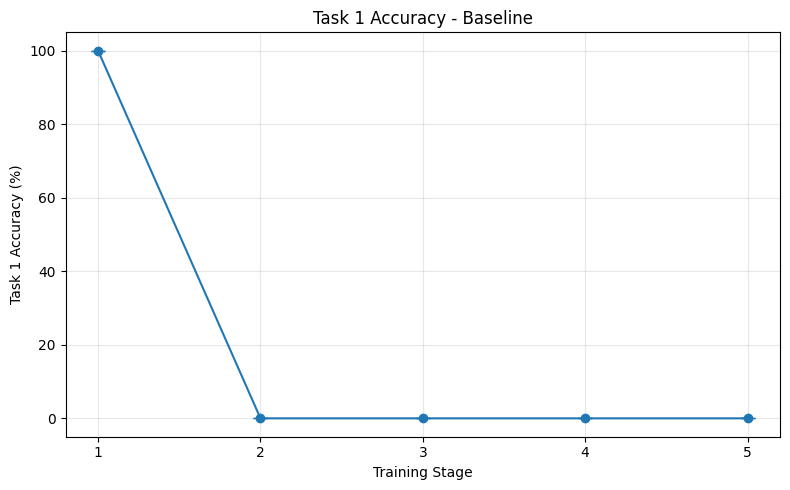

In [16]:
stages = np.arange(
    1,
    NUM_TASKS + 1
)

task1_mean = np.mean(
    baseline_task1,
    axis=0
)

task1_std = np.std(
    baseline_task1,
    axis=0
)

plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    stages,
    task1_mean,
    yerr=task1_std,
    marker="o",
    capsize=5
)

plt.xlabel(
    "Training Stage"
)

plt.ylabel(
    "Task 1 Accuracy (%)"
)

plt.title(
    "Task 1 Accuracy - Baseline"
)

plt.xticks(
    stages
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/task1_baseline.png",
    dpi=200
)

plt.show()


In [17]:
def run_upper_bound(seed):

    print("\n")
    print("=" * 70)
    print(
        f"UPPER BOUND - SEED {seed}"
    )
    print("=" * 70)

    set_seed(seed)

    model = SmallMLP().to(
        DEVICE
    )

    optimizer = create_optimizer(
        model
    )

    print(
        "\nTraining on all 10 "
        "classes simultaneously..."
    )

    train_model(
        model,
        train_dataset,
        EPOCHS_PER_TASK,
        optimizer
    )

    accuracy = evaluate(
        model,
        test_dataset
    )

    print(
        f"\nJoint training accuracy: "
        f"{accuracy:.2f}%"
    )

    return accuracy


upper_results = []

for seed in SEEDS:

    accuracy = run_upper_bound(
        seed
    )

    upper_results.append(
        accuracy
    )


upper_mean = np.mean(
    upper_results
)

upper_std = np.std(
    upper_results
)



UPPER BOUND - SEED 42

Training on all 10 classes simultaneously...
    Epoch 1/3 | Loss: 0.2668 | Train Acc: 91.81%
    Epoch 2/3 | Loss: 0.0874 | Train Acc: 97.28%
    Epoch 3/3 | Loss: 0.0608 | Train Acc: 98.07%

Joint training accuracy: 97.57%


UPPER BOUND - SEED 123

Training on all 10 classes simultaneously...
    Epoch 1/3 | Loss: 0.2560 | Train Acc: 92.30%
    Epoch 2/3 | Loss: 0.0925 | Train Acc: 97.14%
    Epoch 3/3 | Loss: 0.0580 | Train Acc: 98.18%

Joint training accuracy: 97.36%


UPPER BOUND - SEED 2026

Training on all 10 classes simultaneously...
    Epoch 1/3 | Loss: 0.2587 | Train Acc: 92.31%
    Epoch 2/3 | Loss: 0.0892 | Train Acc: 97.33%
    Epoch 3/3 | Loss: 0.0587 | Train Acc: 98.17%

Joint training accuracy: 97.72%


In [18]:

class FrozenFeatureClassifier(
    nn.Module
):

    def __init__(
        self,
        feature_dim=128
    ):

        super().__init__()

        self.classifier = nn.Linear(
            feature_dim,
            2
        )

    def forward(self, x):

        return self.classifier(x)


@torch.no_grad()
def extract_features(
    model,
    dataset
):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model.eval()

    features_list = []
    labels_list = []

    for images, labels in loader:

        images = images.to(
            DEVICE
        )

        features = model.extract_features(
            images
        )

        features_list.append(
            features.cpu()
        )

        labels_list.append(
            torch.tensor(
                labels,
                dtype=torch.long
            )
        )

    features = torch.cat(
        features_list,
        dim=0
    )

    labels = torch.cat(
        labels_list,
        dim=0
    )

    return features, labels


def run_diagnosis(seed):

    print("\n")
    print("=" * 70)
    print(
        f"DIAGNOSIS - SEED {seed}"
    )
    print("=" * 70)

    set_seed(seed)

    model = SmallMLP().to(
        DEVICE
    )

    optimizer = create_optimizer(
        model
    )

    # Train sequential baseline
    for task_id in range(
        NUM_TASKS
    ):

        print(
            f"\nTraining Task "
            f"{task_id + 1}: "
            f"{TASKS[task_id]}"
        )

        train_model(
            model,
            train_tasks[task_id],
            EPOCHS_PER_TASK,
            optimizer
        )

    # Original classifier
    original_accuracy = evaluate(
        model,
        test_tasks[0]
    )

    print(
        f"\nOriginal final model "
        f"Task 1 accuracy: "
        f"{original_accuracy:.2f}%"
    )

    # Extract features from Task 1
    train_features, train_labels = (
        extract_features(
            model,
            train_tasks[0]
        )
    )

    test_features, test_labels = (
        extract_features(
            model,
            test_tasks[0]
        )
    )

    # New 2-class diagnostic classifier
    classifier = FrozenFeatureClassifier(
        feature_dim=128
    ).to(DEVICE)

    diagnostic_optimizer = optim.SGD(
        classifier.parameters(),
        lr=0.05,
        momentum=0.9
    )

    criterion = nn.CrossEntropyLoss()

    feature_dataset = torch.utils.data.TensorDataset(
        train_features,
        train_labels
    )

    feature_loader = DataLoader(
        feature_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    for epoch in range(5):

        classifier.train()

        for features, labels in feature_loader:

            features = features.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE,
                dtype=torch.long
            )

            diagnostic_optimizer.zero_grad()

            outputs = classifier(
                features
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            diagnostic_optimizer.step()

    # Test diagnostic classifier
    classifier.eval()

    with torch.no_grad():

        test_features_device = (
            test_features.to(
                DEVICE
            )
        )

        outputs = classifier(
            test_features_device
        )

        predictions = outputs.argmax(
            dim=1
        ).cpu()

    fresh_classifier_accuracy = (
        100.0
        *
        (
            predictions == test_labels
        ).float().mean().item()
    )

    print(
        f"Fresh classifier on "
        f"frozen features: "
        f"{fresh_classifier_accuracy:.2f}%"
    )

    return (
        original_accuracy,
        fresh_classifier_accuracy
    )


diagnosis_results = []

for seed in SEEDS:

    result = run_diagnosis(
        seed
    )

    diagnosis_results.append(
        result
    )


diagnosis_results = np.array(
    diagnosis_results
)


diagnosis_df = pd.DataFrame(
    diagnosis_results,
    columns=[
        "Original_Task1_Accuracy",
        "Fresh_Classifier_Accuracy"
    ]
)

diagnosis_df["Seed"] = SEEDS

diagnosis_df = diagnosis_df[
    [
        "Seed",
        "Original_Task1_Accuracy",
        "Fresh_Classifier_Accuracy"
    ]
]

diagnosis_df.to_csv(
    f"{RESULTS_DIR}/diagnosis.csv",
    index=False
)


diagnosis_original_mean = np.mean(
    diagnosis_results[:, 0]
)

diagnosis_original_std = np.std(
    diagnosis_results[:, 0]
)

diagnosis_fresh_mean = np.mean(
    diagnosis_results[:, 1]
)

diagnosis_fresh_std = np.std(
    diagnosis_results[:, 1]
)


print("\n")
print("=" * 70)
print("DIAGNOSIS RESULTS")
print("=" * 70)

print(
    f"Original Task 1: "
    f"{diagnosis_original_mean:.2f}% "
    f"+/- "
    f"{diagnosis_original_std:.2f}"
)

print(
    f"Fresh classifier: "
    f"{diagnosis_fresh_mean:.2f}% "
    f"+/- "
    f"{diagnosis_fresh_std:.2f}"
)

if diagnosis_fresh_mean > 70:

    diagnosis = (
        "H2 is supported: the feature "
        "representation still contains "
        "useful information about Task 1, "
        "while the original classifier "
        "has become biased."
    )

else:

    diagnosis = (
        "H1 is supported: the feature "
        "representation itself has lost "
        "substantial information about "
        "Task 1."
    )

print("\nVerdict:")
print(diagnosis)

print(
    "\nLimitation: this diagnostic does "
    "not completely rule out a combination "
    "of feature degradation and classifier bias."
)



DIAGNOSIS - SEED 42

Training Task 1: (0, 1)
    Epoch 1/3 | Loss: 0.1156 | Train Acc: 98.04%
    Epoch 2/3 | Loss: 0.0059 | Train Acc: 99.89%
    Epoch 3/3 | Loss: 0.0018 | Train Acc: 99.95%

Training Task 2: (2, 3)
    Epoch 1/3 | Loss: 0.5368 | Train Acc: 88.10%
    Epoch 2/3 | Loss: 0.0562 | Train Acc: 98.09%
    Epoch 3/3 | Loss: 0.0322 | Train Acc: 98.92%

Training Task 3: (4, 5)
    Epoch 1/3 | Loss: 0.5179 | Train Acc: 85.59%
    Epoch 2/3 | Loss: 0.0192 | Train Acc: 99.46%
    Epoch 3/3 | Loss: 0.0113 | Train Acc: 99.66%

Training Task 4: (6, 7)
    Epoch 1/3 | Loss: 0.4723 | Train Acc: 88.15%
    Epoch 2/3 | Loss: 0.0049 | Train Acc: 99.84%
    Epoch 3/3 | Loss: 0.0033 | Train Acc: 99.90%

Training Task 5: (8, 9)
    Epoch 1/3 | Loss: 0.8358 | Train Acc: 76.67%
    Epoch 2/3 | Loss: 0.0689 | Train Acc: 97.97%
    Epoch 3/3 | Loss: 0.0565 | Train Acc: 98.31%

Original final model Task 1 accuracy: 0.00%


/tmp/ipykernel_16/4265129929.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(


Fresh classifier on frozen features: 62.98%


DIAGNOSIS - SEED 123

Training Task 1: (0, 1)
    Epoch 1/3 | Loss: 0.0988 | Train Acc: 98.91%
    Epoch 2/3 | Loss: 0.0121 | Train Acc: 99.85%
    Epoch 3/3 | Loss: 0.0040 | Train Acc: 99.91%

Training Task 2: (2, 3)
    Epoch 1/3 | Loss: 0.7522 | Train Acc: 88.12%
    Epoch 2/3 | Loss: 0.0499 | Train Acc: 98.25%
    Epoch 3/3 | Loss: 0.0312 | Train Acc: 98.78%

Training Task 3: (4, 5)
    Epoch 1/3 | Loss: 0.6853 | Train Acc: 87.34%
    Epoch 2/3 | Loss: 0.0252 | Train Acc: 99.24%
    Epoch 3/3 | Loss: 0.0153 | Train Acc: 99.50%

Training Task 4: (6, 7)
    Epoch 1/3 | Loss: 0.6169 | Train Acc: 83.21%
    Epoch 2/3 | Loss: 0.0062 | Train Acc: 99.84%
    Epoch 3/3 | Loss: 0.0034 | Train Acc: 99.92%

Training Task 5: (8, 9)
    Epoch 1/3 | Loss: 1.0828 | Train Acc: 64.19%
    Epoch 2/3 | Loss: 0.0553 | Train Acc: 98.21%
    Epoch 3/3 | Loss: 0.0386 | Train Acc: 98.75%

Original final model Task 1 accuracy: 0.00%
Fresh classifier on frozen f

In [19]:
def create_replay_buffer(
    seen_task_datasets,
    buffer_size
):

    """
    Creates a balanced replay buffer.

    IMPORTANT:
        Returns:
            images -> Tensor [N, 1, 28, 28]
            labels -> Tensor [N]

    Therefore DataLoader will never receive
    a mixture of Python integers and tensors.
    """

    num_tasks = len(
        seen_task_datasets
    )

    if num_tasks == 0:
        return None, None

    # Number per task
    base_amount = (
        buffer_size // num_tasks
    )

    remainder = (
        buffer_size % num_tasks
    )

    buffer_images = []
    buffer_labels = []

    for task_id, dataset in enumerate(
        seen_task_datasets
    ):

        amount = base_amount

        # Distribute remaining examples
        if task_id < remainder:
            amount += 1

        # Safety
        amount = min(
            amount,
            len(dataset)
        )

        indices = np.random.choice(
            len(dataset),
            size=amount,
            replace=False
        )

        for index in indices:

            image, label = dataset[
                index
            ]

            # -------------------------
            # Image -> Tensor
            # -------------------------

            if not torch.is_tensor(image):

                image = torch.tensor(
                    image,
                    dtype=torch.float32
                )

            else:

                image = image.float()

            # -------------------------
            # Label -> Tensor
            # -------------------------

            label = torch.tensor(
                int(label),
                dtype=torch.long
            )

            buffer_images.append(
                image
            )

            buffer_labels.append(
                label
            )

    # ---------------------------------
    # Convert EVERYTHING to tensors
    # ---------------------------------

    if len(buffer_images) == 0:

        return None, None

    buffer_images = torch.stack(
        buffer_images,
        dim=0
    )

    buffer_labels = torch.stack(
        buffer_labels,
        dim=0
    )

    return (
        buffer_images,
        buffer_labels
    )



In [20]:
class ReplayDataset(Dataset):

    def __init__(
        self,
        current_dataset,
        memory_images=None,
        memory_labels=None
    ):

        self.images = []
        self.labels = []

        # --------------------------------
        # Current task
        # --------------------------------

        for i in range(
            len(current_dataset)
        ):

            image, label = (
                current_dataset[i]
            )

            if not torch.is_tensor(image):

                image = torch.tensor(
                    image,
                    dtype=torch.float32
                )

            else:

                image = image.float()

            label = int(label)

            self.images.append(
                image
            )

            self.labels.append(
                label
            )

        # --------------------------------
        # Replay memory
        # --------------------------------

        if (
            memory_images is not None
            and memory_labels is not None
        ):

            for i in range(
                len(memory_images)
            ):

                image = memory_images[i]

                label = memory_labels[i]

                # Image must be Tensor
                if not torch.is_tensor(
                    image
                ):

                    image = torch.tensor(
                        image,
                        dtype=torch.float32
                    )

                else:

                    image = image.float()

                # Label -> Python int
                if torch.is_tensor(
                    label
                ):

                    label = int(
                        label.item()
                    )

                else:

                    label = int(label)

                self.images.append(
                    image
                )

                self.labels.append(
                    label
                )

    def __len__(self):

        return len(
            self.images
        )

    def __getitem__(self, index):

        # --------------------------------
        # GUARANTEE:
        #
        # image = Tensor
        # label = int
        # --------------------------------

        image = self.images[index]

        label = self.labels[index]

        if not torch.is_tensor(image):

            image = torch.tensor(
                image,
                dtype=torch.float32
            )

        else:

            image = image.float()

        label = int(label)

        return image, label


In [21]:
def run_replay(
    seed,
    buffer_size=200
):

    print("\n")
    print("=" * 70)
    print(
        f"REPLAY - SEED {seed} "
        f"- BUFFER {buffer_size}"
    )
    print("=" * 70)

    set_seed(seed)

    model = SmallMLP().to(
        DEVICE
    )

    optimizer = create_optimizer(
        model
    )

    R = np.full(
        (NUM_TASKS, NUM_TASKS),
        np.nan
    )

    task1_accuracy = []

    memory_images = None
    memory_labels = None

    seen_datasets = []

    for task_id in range(
        NUM_TASKS
    ):

        print(
            f"\nTraining Task "
            f"{task_id + 1}: "
            f"{TASKS[task_id]}"
        )

        current_dataset = (
            train_tasks[task_id]
        )

        # --------------------------------
        # Create training dataset
        # --------------------------------

        if (
            memory_images is None
            or buffer_size == 0
        ):

            training_dataset = (
                current_dataset
            )

        else:

            training_dataset = ReplayDataset(
                current_dataset,
                memory_images,
                memory_labels
            )

        print(
            f"Training examples: "
            f"{len(training_dataset)}"
        )

        # --------------------------------
        # TRAIN
        # --------------------------------

        train_model(
            model,
            training_dataset,
            EPOCHS_PER_TASK,
            optimizer
        )

        # --------------------------------
        # EVALUATE
        # --------------------------------

        accuracies = evaluate_seen_tasks(
            model,
            test_tasks,
            task_id
        )

        for j, acc in enumerate(
            accuracies
        ):

            R[
                task_id,
                j
            ] = acc

        task1_accuracy.append(
            R[task_id, 0]
        )

        print(
            f"\nAfter Task "
            f"{task_id + 1}:"
        )

        for j, acc in enumerate(
            accuracies
        ):

            print(
                f"    Task {j + 1}: "
                f"{acc:.2f}%"
            )

        # --------------------------------
        # UPDATE REPLAY MEMORY
        # --------------------------------

        if buffer_size > 0:

            seen_datasets.append(
                current_dataset
            )

            (
                memory_images,
                memory_labels
            ) = create_replay_buffer(
                seen_datasets,
                buffer_size
            )

            print(
                f"Replay memory: "
                f"{len(memory_images)} "
                f"images"
            )

            print(
                f"Replay labels shape: "
                f"{memory_labels.shape}"
            )

    return (
        R,
        task1_accuracy
    )


In [22]:
replay_matrices = []
replay_task1 = []

for seed in SEEDS:

    R, task1 = run_replay(
        seed,
        buffer_size=200
    )

    replay_matrices.append(
        R
    )

    replay_task1.append(
        task1
    )


replay_matrices = np.array(
    replay_matrices
)

replay_task1 = np.array(
    replay_task1
)





REPLAY - SEED 42 - BUFFER 200

Training Task 1: (0, 1)
Training examples: 12665
    Epoch 1/3 | Loss: 0.1156 | Train Acc: 98.04%
    Epoch 2/3 | Loss: 0.0059 | Train Acc: 99.89%
    Epoch 3/3 | Loss: 0.0018 | Train Acc: 99.95%

After Task 1:
    Task 1: 99.91%
Replay memory: 200 images
Replay labels shape: torch.Size([200])

Training Task 2: (2, 3)
Training examples: 12289
    Epoch 1/3 | Loss: 0.6110 | Train Acc: 86.35%
    Epoch 2/3 | Loss: 0.0904 | Train Acc: 96.70%
    Epoch 3/3 | Loss: 0.0505 | Train Acc: 98.36%

After Task 2:
    Task 1: 76.31%
    Task 2: 98.53%
Replay memory: 200 images
Replay labels shape: torch.Size([200])

Training Task 3: (4, 5)
Training examples: 11463
    Epoch 1/3 | Loss: 0.7333 | Train Acc: 86.01%
    Epoch 2/3 | Loss: 0.0705 | Train Acc: 98.10%
    Epoch 3/3 | Loss: 0.0406 | Train Acc: 98.61%

After Task 3:
    Task 1: 37.64%
    Task 2: 37.46%
    Task 3: 99.73%
Replay memory: 200 images
Replay labels shape: torch.Size([200])

Training Task 4: (6, 7

In [23]:
replay_mean_R = np.nanmean(
    replay_matrices,
    axis=0
)

replay_std_R = np.nanstd(
    replay_matrices,
    axis=0
)

replay_table = pd.DataFrame(
    replay_mean_R,
    index=[
        "After Task 1",
        "After Task 2",
        "After Task 3",
        "After Task 4",
        "After Task 5"
    ],
    columns=[
        "Task 1",
        "Task 2",
        "Task 3",
        "Task 4",
        "Task 5"
    ]
)

print("\n")
print("=" * 70)
print("REPLAY ACCURACY MATRIX")
print("=" * 70)

print(
    replay_table.round(2)
)

replay_table.to_csv(
    f"{RESULTS_DIR}/replay_R.csv"
)




REPLAY ACCURACY MATRIX
              Task 1  Task 2  Task 3  Task 4  Task 5
After Task 1   99.94     NaN     NaN     NaN     NaN
After Task 2   82.27   98.60     NaN     NaN     NaN
After Task 3   53.10   58.64   99.54     NaN     NaN
After Task 4   26.57   46.95    4.41   99.53     NaN
After Task 5   20.36   20.06    2.83   25.65   98.54


/tmp/ipykernel_16/213369867.py:1: RuntimeWarning: Mean of empty slice
  replay_mean_R = np.nanmean(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [24]:
replay_final = []

replay_forgetting = []

for R in replay_matrices:

    replay_final.append(
        final_average_accuracy(R)
    )

    replay_forgetting.append(
        average_forgetting(R)
    )


replay_final_mean = np.mean(
    replay_final
)

replay_final_std = np.std(
    replay_final
)

replay_forgetting_mean = np.mean(
    replay_forgetting
)

replay_forgetting_std = np.std(
    replay_forgetting
)


print("\n")
print("=" * 70)
print("REPLAY METRICS")
print("=" * 70)

print(
    f"Final Average Accuracy: "
    f"{replay_final_mean:.2f}% "
    f"+/- "
    f"{replay_final_std:.2f}"
)

print(
    f"Average Forgetting: "
    f"{replay_forgetting_mean:.2f} "
    f"+/- "
    f"{replay_forgetting_std:.2f}"
)




REPLAY METRICS
Final Average Accuracy: 33.49% +/- 2.09
Average Forgetting: 82.18 +/- 2.61


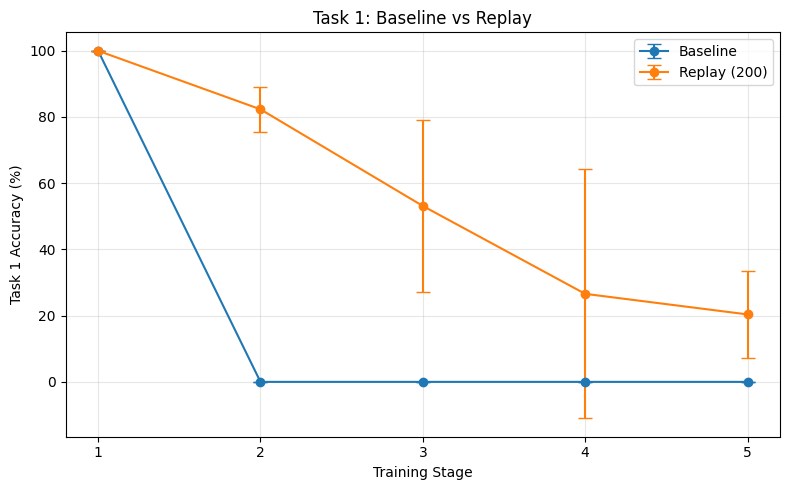

In [25]:
replay_task1_mean = np.mean(
    replay_task1,
    axis=0
)

replay_task1_std = np.std(
    replay_task1,
    axis=0
)

plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    stages,
    task1_mean,
    yerr=task1_std,
    marker="o",
    capsize=5,
    label="Baseline"
)

plt.errorbar(
    stages,
    replay_task1_mean,
    yerr=replay_task1_std,
    marker="o",
    capsize=5,
    label="Replay (200)"
)

plt.xlabel(
    "Training Stage"
)

plt.ylabel(
    "Task 1 Accuracy (%)"
)

plt.title(
    "Task 1: Baseline vs Replay"
)

plt.xticks(
    stages
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/task1_replay.png",
    dpi=200
)

plt.show()


In [26]:
BUFFER_SIZES = [
    0,
    50,
    100,
    200
]

knob_results = []

for buffer_size in BUFFER_SIZES:

    print("\n")
    print("=" * 70)
    print(
        f"BUFFER SIZE = "
        f"{buffer_size}"
    )
    print("=" * 70)

    seed_final = []
    seed_forgetting = []

    for seed in SEEDS:

        if buffer_size == 0:

            R, _task1, _model = (
                run_baseline(seed)
            )

        else:

            R, _task1 = run_replay(
                seed,
                buffer_size
            )

        seed_final.append(
            final_average_accuracy(R)
        )

        seed_forgetting.append(
            average_forgetting(R)
        )

    knob_results.append({

        "buffer_size":
            buffer_size,

        "final_accuracy_mean":
            np.mean(seed_final),

        "final_accuracy_std":
            np.std(seed_final),

        "forgetting_mean":
            np.mean(seed_forgetting),

        "forgetting_std":
            np.std(seed_forgetting)
    })


knob_df = pd.DataFrame(
    knob_results
)

print("\n")
print("=" * 70)
print("BUFFER SIZE RESULTS")
print("=" * 70)

print(
    knob_df.round(2)
)


knob_df.to_csv(
    f"{RESULTS_DIR}/buffer_knob.csv",
    index=False
)




BUFFER SIZE = 0


BASELINE - SEED 42

Training Task 1: (0, 1)
    Epoch 1/3 | Loss: 0.1156 | Train Acc: 98.04%
    Epoch 2/3 | Loss: 0.0059 | Train Acc: 99.89%
    Epoch 3/3 | Loss: 0.0018 | Train Acc: 99.95%

After Task 1:
    Task 1: 99.91%

Training Task 2: (2, 3)
    Epoch 1/3 | Loss: 0.5856 | Train Acc: 87.11%
    Epoch 2/3 | Loss: 0.0634 | Train Acc: 97.73%
    Epoch 3/3 | Loss: 0.0379 | Train Acc: 98.59%

After Task 2:
    Task 1: 0.00%
    Task 2: 99.12%

Training Task 3: (4, 5)
    Epoch 1/3 | Loss: 0.6620 | Train Acc: 84.76%
    Epoch 2/3 | Loss: 0.0230 | Train Acc: 99.28%
    Epoch 3/3 | Loss: 0.0161 | Train Acc: 99.51%

After Task 3:
    Task 1: 0.00%
    Task 2: 0.00%
    Task 3: 99.57%

Training Task 4: (6, 7)
    Epoch 1/3 | Loss: 0.7835 | Train Acc: 79.24%
    Epoch 2/3 | Loss: 0.0095 | Train Acc: 99.80%
    Epoch 3/3 | Loss: 0.0046 | Train Acc: 99.88%

After Task 4:
    Task 1: 0.00%
    Task 2: 0.00%
    Task 3: 0.00%
    Task 4: 99.55%

Training Task 5: (8, 9)
    

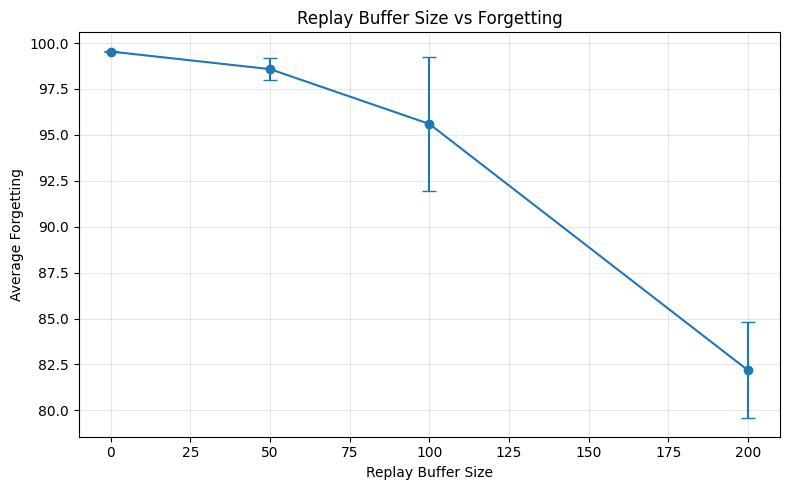

In [27]:
plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    knob_df["buffer_size"],
    knob_df["forgetting_mean"],
    yerr=knob_df["forgetting_std"],
    marker="o",
    capsize=5
)

plt.xlabel(
    "Replay Buffer Size"
)

plt.ylabel(
    "Average Forgetting"
)

plt.title(
    "Replay Buffer Size vs Forgetting"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/forgetting_vs_buffer.png",
    dpi=200
)

plt.show()


In [28]:
summary = pd.DataFrame([

    {
        "Method":
            "Joint Training Upper Bound",

        "Final Accuracy (%)":
            upper_mean,

        "Accuracy Std":
            upper_std,

        "Average Forgetting":
            0.0,

        "Forgetting Std":
            0.0
    },

    {
        "Method":
            "Sequential Baseline",

        "Final Accuracy (%)":
            baseline_final_mean,

        "Accuracy Std":
            baseline_final_std,

        "Average Forgetting":
            baseline_forgetting_mean,

        "Forgetting Std":
            baseline_forgetting_std
    },

    {
        "Method":
            "Experience Replay (200)",

        "Final Accuracy (%)":
            replay_final_mean,

        "Accuracy Std":
            replay_final_std,

        "Average Forgetting":
            replay_forgetting_mean,

        "Forgetting Std":
            replay_forgetting_std
    }

])


summary.to_csv(
    f"{RESULTS_DIR}/summary.csv",
    index=False
)

In [29]:
print("\n")
print("=" * 80)
print("FINAL PROJECT RESULTS")
print("=" * 80)

print(
    summary.round(2).to_string(
        index=False
    )
)

print("\n")
print("=" * 80)
print("DIAGNOSIS")
print("=" * 80)

print(
    f"Original Task 1: "
    f"{diagnosis_original_mean:.2f}% "
    f"+/- "
    f"{diagnosis_original_std:.2f}"
)

print(
    f"Fresh classifier: "
    f"{diagnosis_fresh_mean:.2f}% "
    f"+/- "
    f"{diagnosis_fresh_std:.2f}"
)

print("\nVerdict:")
print(diagnosis)


print("\n")
print("=" * 80)
print("FILES CREATED")
print("=" * 80)

files = [
    f"{RESULTS_DIR}/baseline_R.csv",
    f"{RESULTS_DIR}/replay_R.csv",
    f"{RESULTS_DIR}/diagnosis.csv",
    f"{RESULTS_DIR}/buffer_knob.csv",
    f"{RESULTS_DIR}/summary.csv",
    f"{PLOTS_DIR}/task1_baseline.png",
    f"{PLOTS_DIR}/task1_replay.png",
    f"{PLOTS_DIR}/forgetting_vs_buffer.png"
]

for file in files:

    print(
        "✓",
        file
    )


print("\n")
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)



FINAL PROJECT RESULTS
                    Method  Final Accuracy (%)  Accuracy Std  Average Forgetting  Forgetting Std
Joint Training Upper Bound               97.55          0.15                0.00            0.00
       Sequential Baseline               19.66          0.06               99.54            0.04
   Experience Replay (200)               33.49          2.09               82.18            2.61


DIAGNOSIS
Original Task 1: 0.00% +/- 0.00
Fresh classifier: 72.10% +/- 16.22

Verdict:
H2 is supported: the feature representation still contains useful information about Task 1, while the original classifier has become biased.


FILES CREATED
✓ results/baseline_R.csv
✓ results/replay_R.csv
✓ results/diagnosis.csv
✓ results/buffer_knob.csv
✓ results/summary.csv
✓ plots/task1_baseline.png
✓ plots/task1_replay.png
✓ plots/forgetting_vs_buffer.png


EXPERIMENT COMPLETE


✓ Required project variables found.
✓ FixedReplayDataset created.
✓ Fixed replay-buffer function created.
✓ run_replay() created successfully.


TESTING REPLAY FUNCTION


REPLAY EXPERIMENT | Seed=42 | Buffer=200


Training Task 1: (0, 1)
Training examples: 12665
    Epoch 1/3 | Loss: 0.1156 | Train Acc: 98.04%
    Epoch 2/3 | Loss: 0.0059 | Train Acc: 99.89%
    Epoch 3/3 | Loss: 0.0018 | Train Acc: 99.95%

After Task 1:
    Task 1: 99.91%
Replay memory: 200 images
Memory image shape: (200, 1, 28, 28)
Memory label shape: (200,)


Training Task 2: (2, 3)
Training examples: 12289
    Epoch 1/3 | Loss: 0.6110 | Train Acc: 86.35%
    Epoch 2/3 | Loss: 0.0904 | Train Acc: 96.70%
    Epoch 3/3 | Loss: 0.0505 | Train Acc: 98.36%

After Task 2:
    Task 1: 76.31%
    Task 2: 98.53%
Replay memory: 200 images
Memory image shape: (200, 1, 28, 28)
Memory label shape: (200,)


Training Task 3: (4, 5)
Training examples: 11463
    Epoch 1/3 | Loss: 0.7333 | Train Acc: 86.01%
    Epoch 2/3 | Loss: 0.0

/tmp/ipykernel_16/3383480676.py:598: RuntimeWarning: Mean of empty slice
  replay_mean_R = np.nanmean(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


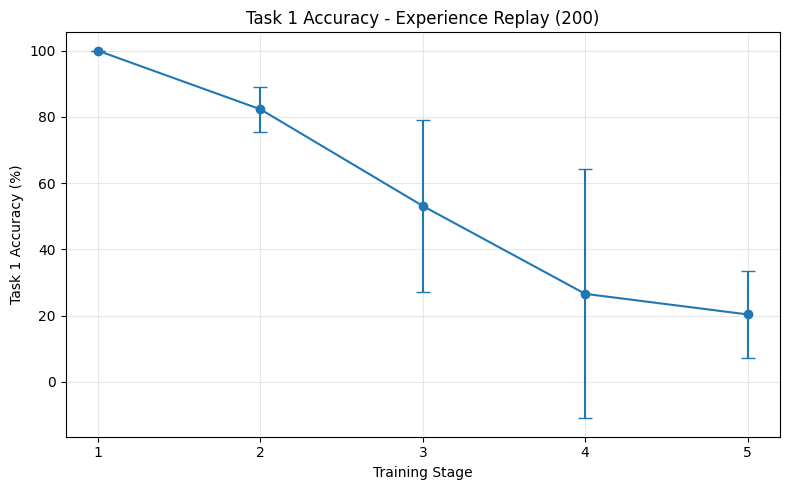

✓ Saved: plots/task1_replay.png


BUFFER SIZE EXPERIMENT: 0


BASELINE - SEED 42

Training Task 1: (0, 1)
    Epoch 1/3 | Loss: 0.1156 | Train Acc: 98.04%
    Epoch 2/3 | Loss: 0.0059 | Train Acc: 99.89%
    Epoch 3/3 | Loss: 0.0018 | Train Acc: 99.95%

After Task 1:
    Task 1: 99.91%

Training Task 2: (2, 3)
    Epoch 1/3 | Loss: 0.5856 | Train Acc: 87.11%
    Epoch 2/3 | Loss: 0.0634 | Train Acc: 97.73%
    Epoch 3/3 | Loss: 0.0379 | Train Acc: 98.59%

After Task 2:
    Task 1: 0.00%
    Task 2: 99.12%

Training Task 3: (4, 5)
    Epoch 1/3 | Loss: 0.6620 | Train Acc: 84.76%
    Epoch 2/3 | Loss: 0.0230 | Train Acc: 99.28%
    Epoch 3/3 | Loss: 0.0161 | Train Acc: 99.51%

After Task 3:
    Task 1: 0.00%
    Task 2: 0.00%
    Task 3: 99.57%

Training Task 4: (6, 7)
    Epoch 1/3 | Loss: 0.7835 | Train Acc: 79.24%
    Epoch 2/3 | Loss: 0.0095 | Train Acc: 99.80%
    Epoch 3/3 | Loss: 0.0046 | Train Acc: 99.88%

After Task 4:
    Task 1: 0.00%
    Task 2: 0.00%
    Task 3: 0.00%
    Ta

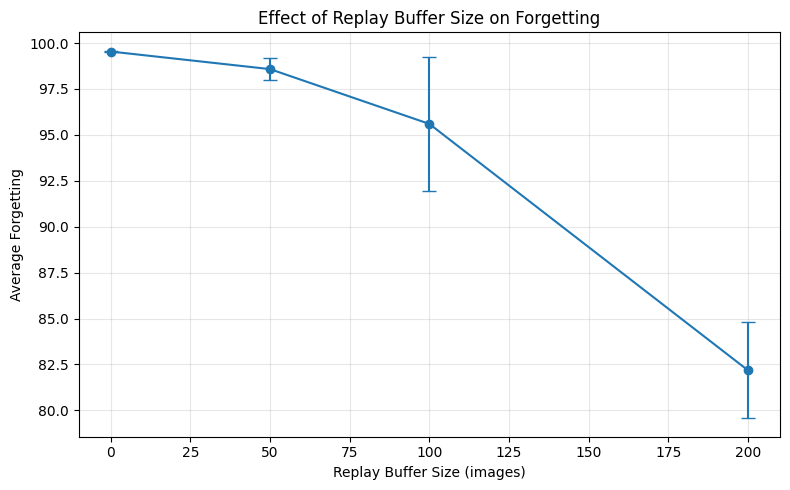

✓ Saved: plots/forgetting_vs_buffer.png


REPLAY REPAIR COMPLETE
Replay Final Accuracy: 33.49% +/- 2.09
Replay Average Forgetting: 82.18 +/- 2.61

Files created:
✓ results/replay_R.csv
✓ results/buffer_knob.csv
✓ plots/task1_replay.png
✓ plots/forgetting_vs_buffer.png


In [30]:
# ============================================================
# FULL REPAIR CODE
# Fixes:
#   1. NameError: run_replay is not defined
#   2. NameError: knob_df is not defined
#   3. Mean of empty slice
#   4. Degrees of freedom <= 0
#   5. ValueError: x and y must have same size
#   6. Replay buffer Tensor/int collate error
#
# Run this AFTER your imports, MNIST datasets, TASKS,
# SmallMLP, train_model, evaluate, and evaluate_seen_tasks
# have been defined.
# ============================================================


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "SEEDS",
    "TASKS",
    "NUM_TASKS",
    "BATCH_SIZE",
    "EPOCHS_PER_TASK",
    "DEVICE",
    "train_tasks",
    "test_tasks",
    "SmallMLP",
    "create_optimizer",
    "train_model",
    "evaluate_seen_tasks"
]

missing = [
    name
    for name in required_variables
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "The following variables/functions are missing:\n"
        + "\n".join(missing)
        + "\n\n"
        "Please run your main setup/model cells first."
    )

print("✓ Required project variables found.")


# ============================================================
# 2. SAFE REPLAY DATASET
# ============================================================

class FixedReplayDataset(Dataset):

    def __init__(
        self,
        current_dataset,
        memory_images=None,
        memory_labels=None
    ):

        self.images = []
        self.labels = []

        # ----------------------------------------
        # Current task
        # ----------------------------------------

        for i in range(
            len(current_dataset)
        ):

            image, label = current_dataset[i]

            image = torch.as_tensor(
                image,
                dtype=torch.float32
            )

            label = int(label)

            self.images.append(image)
            self.labels.append(label)

        # ----------------------------------------
        # Old replay examples
        # ----------------------------------------

        if (
            memory_images is not None
            and memory_labels is not None
        ):

            for i in range(
                len(memory_images)
            ):

                image = torch.as_tensor(
                    memory_images[i],
                    dtype=torch.float32
                )

                label = memory_labels[i]

                if torch.is_tensor(label):

                    label = int(
                        label.item()
                    )

                else:

                    label = int(label)

                self.images.append(image)
                self.labels.append(label)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        image = torch.as_tensor(
            self.images[index],
            dtype=torch.float32
        )

        label = int(
            self.labels[index]
        )

        return image, label


print("✓ FixedReplayDataset created.")


# ============================================================
# 3. SAFE REPLAY BUFFER
# ============================================================

def create_fixed_replay_buffer(
    seen_task_datasets,
    buffer_size
):

    if buffer_size <= 0:

        return None, None

    if len(seen_task_datasets) == 0:

        return None, None

    num_tasks = len(
        seen_task_datasets
    )

    # ----------------------------------------
    # Balanced allocation
    # ----------------------------------------

    base_size = (
        buffer_size // num_tasks
    )

    remainder = (
        buffer_size % num_tasks
    )

    images = []
    labels = []

    for task_id, dataset in enumerate(
        seen_task_datasets
    ):

        amount = base_size

        if task_id < remainder:

            amount += 1

        amount = min(
            amount,
            len(dataset)
        )

        if amount <= 0:
            continue

        # ------------------------------------
        # Deterministic random selection
        # based on current NumPy seed
        # ------------------------------------

        selected_indices = np.random.choice(
            len(dataset),
            size=amount,
            replace=False
        )

        for idx in selected_indices:

            image, label = dataset[idx]

            image = torch.as_tensor(
                image,
                dtype=torch.float32
            )

            label = torch.tensor(
                int(label),
                dtype=torch.long
            )

            images.append(image)
            labels.append(label)

    if len(images) == 0:

        return None, None

    # ----------------------------------------
    # VERY IMPORTANT:
    # stack tensors
    # ----------------------------------------

    images = torch.stack(
        images,
        dim=0
    )

    labels = torch.stack(
        labels,
        dim=0
    )

    return images, labels


print("✓ Fixed replay-buffer function created.")


# ============================================================
# 4. REPLAY TRAINING FUNCTION
# ============================================================

def run_replay(
    seed,
    buffer_size=200
):

    print("\n")
    print("=" * 70)
    print(
        f"REPLAY EXPERIMENT"
        f" | Seed={seed}"
        f" | Buffer={buffer_size}"
    )
    print("=" * 70)

    # ----------------------------------------
    # Reproducibility
    # ----------------------------------------

    set_seed(seed)

    model = SmallMLP().to(
        DEVICE
    )

    optimizer = create_optimizer(
        model
    )

    # ----------------------------------------
    # Accuracy matrix
    # ----------------------------------------

    R = np.full(
        (NUM_TASKS, NUM_TASKS),
        np.nan,
        dtype=np.float64
    )

    task1_accuracy = []

    # ----------------------------------------
    # Replay memory
    # ----------------------------------------

    memory_images = None
    memory_labels = None

    seen_datasets = []

    # ----------------------------------------
    # Sequential tasks
    # ----------------------------------------

    for task_id in range(
        NUM_TASKS
    ):

        print("\n")
        print(
            f"Training Task "
            f"{task_id + 1}: "
            f"{TASKS[task_id]}"
        )

        current_dataset = (
            train_tasks[task_id]
        )

        # ------------------------------------
        # Create current training dataset
        # ------------------------------------

        if (
            buffer_size <= 0
            or memory_images is None
        ):

            training_dataset = (
                current_dataset
            )

        else:

            training_dataset = (
                FixedReplayDataset(
                    current_dataset,
                    memory_images,
                    memory_labels
                )
            )

        print(
            f"Training examples: "
            f"{len(training_dataset)}"
        )

        # ------------------------------------
        # Train
        # ------------------------------------

        train_model(
            model,
            training_dataset,
            epochs=EPOCHS_PER_TASK,
            optimizer=optimizer
        )

        # ------------------------------------
        # Evaluate ALL seen tasks
        # ------------------------------------

        accuracies = evaluate_seen_tasks(
            model,
            test_tasks,
            task_id
        )

        # ------------------------------------
        # Safety check
        # ------------------------------------

        if len(accuracies) != task_id + 1:

            raise RuntimeError(
                f"Expected "
                f"{task_id + 1} accuracies "
                f"but received "
                f"{len(accuracies)}."
            )

        # ------------------------------------
        # Store R matrix
        # ------------------------------------

        for j, acc in enumerate(
            accuracies
        ):

            R[
                task_id,
                j
            ] = float(acc)

        task1_accuracy.append(
            float(R[task_id, 0])
        )

        # ------------------------------------
        # Print evaluation
        # ------------------------------------

        print(
            f"\nAfter Task "
            f"{task_id + 1}:"
        )

        for j, acc in enumerate(
            accuracies
        ):

            print(
                f"    Task {j + 1}: "
                f"{acc:.2f}%"
            )

        # ------------------------------------
        # UPDATE MEMORY
        # ------------------------------------

        if buffer_size > 0:

            seen_datasets.append(
                current_dataset
            )

            (
                memory_images,
                memory_labels
            ) = create_fixed_replay_buffer(
                seen_datasets,
                buffer_size
            )

            if memory_images is not None:

                print(
                    f"Replay memory: "
                    f"{memory_images.shape[0]} "
                    f"images"
                )

                print(
                    f"Memory image shape: "
                    f"{tuple(memory_images.shape)}"
                )

                print(
                    f"Memory label shape: "
                    f"{tuple(memory_labels.shape)}"
                )

    # ----------------------------------------
    # Final safety check
    # ----------------------------------------

    if np.isnan(R).all():

        raise RuntimeError(
            "R matrix is completely empty. "
            "Replay experiment did not produce results."
        )

    return R, task1_accuracy


print("✓ run_replay() created successfully.")


# ============================================================
# 5. TEST run_replay BEFORE EVERYTHING ELSE
# ============================================================

print("\n")
print("=" * 70)
print("TESTING REPLAY FUNCTION")
print("=" * 70)

test_R, test_task1 = run_replay(
    seed=SEEDS[0],
    buffer_size=200
)

print("\n✓ Replay test completed.")

print(
    "R shape:",
    test_R.shape
)

print(
    "Task 1 stages:",
    test_task1
)

# Check that the matrix contains actual numbers
if np.isnan(test_R).all():

    raise RuntimeError(
        "Replay test produced an empty R matrix."
    )

print(
    "\n✓ R contains valid results."
)


# ============================================================
# 6. RUN REPLAY FOR ALL 3 SEEDS
# ============================================================

replay_matrices = []
replay_task1 = []

for seed in SEEDS:

    print("\n")
    print(
        "#" * 70
    )

    R, task1 = run_replay(
        seed=seed,
        buffer_size=200
    )

    replay_matrices.append(
        R
    )

    replay_task1.append(
        task1
    )


# Convert to NumPy arrays
replay_matrices = np.asarray(
    replay_matrices,
    dtype=np.float64
)

replay_task1 = np.asarray(
    replay_task1,
    dtype=np.float64
)


print("\n")
print("=" * 70)
print("REPLAY ARRAY CHECK")
print("=" * 70)

print(
    "replay_matrices shape:",
    replay_matrices.shape
)

print(
    "replay_task1 shape:",
    replay_task1.shape
)


# ============================================================
# 7. CHECK FOR EMPTY RESULTS
# ============================================================

if replay_matrices.size == 0:

    raise RuntimeError(
        "replay_matrices is empty."
    )

if replay_task1.size == 0:

    raise RuntimeError(
        "replay_task1 is empty."
    )

if np.isnan(replay_matrices).all():

    raise RuntimeError(
        "All replay results are NaN."
    )

print(
    "✓ Replay results are not empty."
)


# ============================================================
# 8. CALCULATE REPLAY MEAN/STD
# ============================================================

replay_mean_R = np.nanmean(
    replay_matrices,
    axis=0
)

replay_std_R = np.nanstd(
    replay_matrices,
    axis=0
)


# ============================================================
# 9. DISPLAY REPLAY MATRIX
# ============================================================

print("\n")
print("=" * 70)
print("REPLAY MEAN ACCURACY MATRIX")
print("=" * 70)

replay_table = pd.DataFrame(

    replay_mean_R,

    index=[
        "After Task 1",
        "After Task 2",
        "After Task 3",
        "After Task 4",
        "After Task 5"
    ],

    columns=[
        "Task 1",
        "Task 2",
        "Task 3",
        "Task 4",
        "Task 5"
    ]
)

print(
    replay_table.round(2)
)


# ============================================================
# 10. SAVE REPLAY R
# ============================================================

os.makedirs(
    "results",
    exist_ok=True
)

replay_table.to_csv(
    "results/replay_R.csv"
)

print(
    "\n✓ Saved:"
    " results/replay_R.csv"
)


# ============================================================
# 11. REPLAY METRICS
# ============================================================

def calculate_final_accuracy(R):

    valid_values = R[-1][
        ~np.isnan(R[-1])
    ]

    if len(valid_values) == 0:

        return np.nan

    return np.mean(
        valid_values
    )


def calculate_forgetting(R):

    values = []

    # Task 1 through Task 4
    for task_id in range(
        NUM_TASKS - 1
    ):

        learned_accuracy = (
            R[task_id, task_id]
        )

        final_accuracy = (
            R[-1, task_id]
        )

        if (
            np.isnan(learned_accuracy)
            or np.isnan(final_accuracy)
        ):

            continue

        values.append(
            learned_accuracy
            - final_accuracy
        )

    if len(values) == 0:

        return np.nan

    return np.mean(values)


replay_final_values = []

replay_forgetting_values = []

for R in replay_matrices:

    replay_final_values.append(
        calculate_final_accuracy(R)
    )

    replay_forgetting_values.append(
        calculate_forgetting(R)
    )


replay_final_values = np.asarray(
    replay_final_values
)

replay_forgetting_values = np.asarray(
    replay_forgetting_values
)


replay_final_mean = np.mean(
    replay_final_values
)

replay_final_std = np.std(
    replay_final_values
)

replay_forgetting_mean = np.mean(
    replay_forgetting_values
)

replay_forgetting_std = np.std(
    replay_forgetting_values
)


print("\n")
print("=" * 70)
print("REPLAY METRICS")
print("=" * 70)

print(
    f"Final Average Accuracy: "
    f"{replay_final_mean:.2f}% "
    f"+/- "
    f"{replay_final_std:.2f}"
)

print(
    f"Average Forgetting: "
    f"{replay_forgetting_mean:.2f} "
    f"+/- "
    f"{replay_forgetting_std:.2f}"
)


# ============================================================
# 12. TASK 1 REPLAY PLOT
# ============================================================

os.makedirs(
    "plots",
    exist_ok=True
)

stages = np.arange(
    1,
    NUM_TASKS + 1
)

replay_task1_mean = np.mean(
    replay_task1,
    axis=0
)

replay_task1_std = np.std(
    replay_task1,
    axis=0
)


# Safety check
print("\n")
print(
    "Stages:",
    stages
)

print(
    "Task 1 mean:",
    replay_task1_mean
)

print(
    "Task 1 std:",
    replay_task1_std
)


if len(stages) != len(
    replay_task1_mean
):

    raise RuntimeError(
        "Plot error: stages and "
        "replay_task1_mean have "
        "different lengths."
    )


plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    stages,
    replay_task1_mean,
    yerr=replay_task1_std,
    marker="o",
    capsize=5
)

plt.xlabel(
    "Training Stage"
)

plt.ylabel(
    "Task 1 Accuracy (%)"
)

plt.title(
    "Task 1 Accuracy - Experience Replay (200)"
)

plt.xticks(
    stages
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "plots/task1_replay.png",
    dpi=200
)

plt.show()

print(
    "✓ Saved:"
    " plots/task1_replay.png"
)


# ============================================================
# 13. BUFFER-SIZE EXPERIMENT
# ============================================================

BUFFER_SIZES = [
    0,
    50,
    100,
    200
]

knob_results = []


for buffer_size in BUFFER_SIZES:

    print("\n")
    print("=" * 70)
    print(
        f"BUFFER SIZE EXPERIMENT: "
        f"{buffer_size}"
    )
    print("=" * 70)

    seed_final_results = []
    seed_forgetting_results = []

    for seed in SEEDS:

        if buffer_size == 0:

            R, task1, _ = run_baseline(
                seed
            )

        else:

            R, task1 = run_replay(
                seed=seed,
                buffer_size=buffer_size
            )

        final_acc = (
            calculate_final_accuracy(R)
        )

        forgetting = (
            calculate_forgetting(R)
        )

        seed_final_results.append(
            final_acc
        )

        seed_forgetting_results.append(
            forgetting
        )

    # ----------------------------------------
    # Remove invalid values
    # ----------------------------------------

    valid_final = [
        x
        for x in seed_final_results
        if not np.isnan(x)
    ]

    valid_forgetting = [
        x
        for x in seed_forgetting_results
        if not np.isnan(x)
    ]

    if len(valid_final) == 0:

        raise RuntimeError(
            f"No valid final accuracy "
            f"for buffer {buffer_size}."
        )

    if len(valid_forgetting) == 0:

        raise RuntimeError(
            f"No valid forgetting "
            f"for buffer {buffer_size}."
        )

    knob_results.append({

        "buffer_size":
            buffer_size,

        "final_accuracy_mean":
            np.mean(valid_final),

        "final_accuracy_std":
            np.std(valid_final),

        "forgetting_mean":
            np.mean(valid_forgetting),

        "forgetting_std":
            np.std(valid_forgetting)
    })


# ============================================================
# 14. CREATE knob_df
# ============================================================

knob_df = pd.DataFrame(
    knob_results
)


print("\n")
print("=" * 70)
print("BUFFER SIZE RESULTS")
print("=" * 70)

print(
    knob_df.round(2)
)


# ============================================================
# 15. SAVE knob_df
# ============================================================

knob_df.to_csv(
    "results/buffer_knob.csv",
    index=False
)

print(
    "\n✓ Saved:"
    " results/buffer_knob.csv"
)


# ============================================================
# 16. VERIFY knob_df
# ============================================================

required_columns = [
    "buffer_size",
    "final_accuracy_mean",
    "final_accuracy_std",
    "forgetting_mean",
    "forgetting_std"
]

for column in required_columns:

    if column not in knob_df.columns:

        raise RuntimeError(
            f"Missing column: {column}"
        )


print(
    "✓ knob_df contains all required columns."
)


# ============================================================
# 17. PLOT BUFFER SIZE VS FORGETTING
# ============================================================

x = knob_df[
    "buffer_size"
].to_numpy()

y = knob_df[
    "forgetting_mean"
].to_numpy()

yerr = knob_df[
    "forgetting_std"
].to_numpy()


print("\nPlot data:")

print(
    "x =",
    x
)

print(
    "y =",
    y
)

print(
    "yerr =",
    yerr
)


if len(x) != len(y):

    raise RuntimeError(
        "x and y have different lengths."
    )

if len(x) != len(yerr):

    raise RuntimeError(
        "x and yerr have different lengths."
    )


plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    x,
    y,
    yerr=yerr,
    marker="o",
    capsize=5
)

plt.xlabel(
    "Replay Buffer Size (images)"
)

plt.ylabel(
    "Average Forgetting"
)

plt.title(
    "Effect of Replay Buffer Size on Forgetting"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "plots/forgetting_vs_buffer.png",
    dpi=200
)

plt.show()

print(
    "✓ Saved:"
    " plots/forgetting_vs_buffer.png"
)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("REPLAY REPAIR COMPLETE")
print("=" * 80)

print(
    f"Replay Final Accuracy: "
    f"{replay_final_mean:.2f}% "
    f"+/- {replay_final_std:.2f}"
)

print(
    f"Replay Average Forgetting: "
    f"{replay_forgetting_mean:.2f} "
    f"+/- {replay_forgetting_std:.2f}"
)

print("\nFiles created:")

print(
    "✓ results/replay_R.csv"
)

print(
    "✓ results/buffer_knob.csv"
)

print(
    "✓ plots/task1_replay.png"
)

print(
    "✓ plots/forgetting_vs_buffer.png"
)